# Lorenz '96 — High-Dimensional Chaos

The [Lorenz '96 system](https://en.wikipedia.org/wiki/Lorenz_96_model) is a
periodic 1D lattice of $N$ coupled variables driven by a constant forcing
$F$. It is a workhorse model for testing data assimilation and ensemble
forecasting methods.

**What you'll learn:**

1. How to set up and run a high-dimensional chaotic ODE in somax
2. How the Hovmoller diagram reveals wave-like propagation
3. How forcing strength $F$ controls the transition to chaos
4. How to compute gradients and run ensembles at scale

## Background

The system consists of $N$ variables $X_k$ on a periodic ring:

$$
\frac{dX_k}{dt}
= \underbrace{(X_{k+1} - X_{k-2})\, X_{k-1}}_{\text{advection}}
  - X_k + F
\qquad k = 1, \ldots, N
$$

with periodic boundary conditions $X_{k+N} = X_k$.

- The quadratic term mimics nonlinear advection (energy-conserving).
- The linear damping $-X_k$ dissipates energy.
- The constant forcing $F$ injects energy.

At $F = 8$ the system is fully chaotic with a doubling time of
approximately 0.42 time units (about 2.1 days if one time unit
equals 5 days).

In [1]:
from __future__ import annotations

import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt

from somax.models import L96State, Lorenz96

## 1. Create the model

We use $N = 360$ variables for a smooth Hovmoller diagram.
Lorenz's original choice was $N = 40$; the higher resolution
reveals finer-scale wave structure on the periodic ring.

In [2]:
N = 360
model = Lorenz96.create(F=8.0)
print(model)

Lorenz96(params=L96Params(F=weak_f32[]))


## 2. Forward simulation

The initial condition is a small perturbation of the $F$-equilibrium
state $X_k = F$ for all $k$. This is an unstable fixed point of the
system — the perturbation grows and the trajectory settles onto the
chaotic attractor.

In [3]:
state0 = L96State.init_state(ndim=N, noise=0.01, F=8.0)

t0, t1, dt = 0.0, 20.0, 0.005
ts = jnp.arange(t0, t1, dt)

sol = model.integrate(
    state0,
    t0=t0,
    t1=t1,
    dt=dt,
    saveat=dfx.SaveAt(ts=ts),
)

print(f"Trajectory shape: {sol.ys.x.shape}")  # (T, N)

Trajectory shape: (4000, 360)


## 3. Hovmoller diagram

A Hovmoller plot shows the state as a function of position (x-axis)
and time (y-axis). The tilted bands reveal wave-like structures
propagating around the periodic ring.

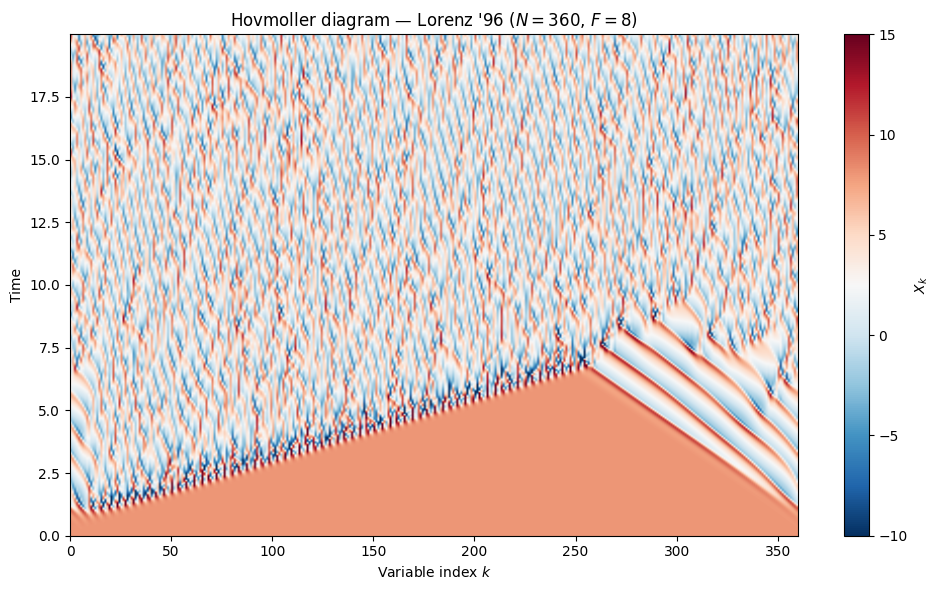

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(
    sol.ys.x,
    aspect="auto",
    origin="lower",
    cmap="RdBu_r",
    vmin=-10,
    vmax=15,
    extent=[0, N, float(ts[0]), float(ts[-1])],
    interpolation="bilinear",
)
ax.set_xlabel("Variable index $k$")
ax.set_ylabel("Time")
ax.set_title(f"Hovmoller diagram — Lorenz '96 ($N={N}$, $F=8$)")
plt.colorbar(im, ax=ax, label="$X_k$")
plt.tight_layout()
plt.show()

## 4. Time series and statistics

Individual variables look like noisy oscillations. The climatological
mean is close to $F$ and the variance grows with forcing strength.

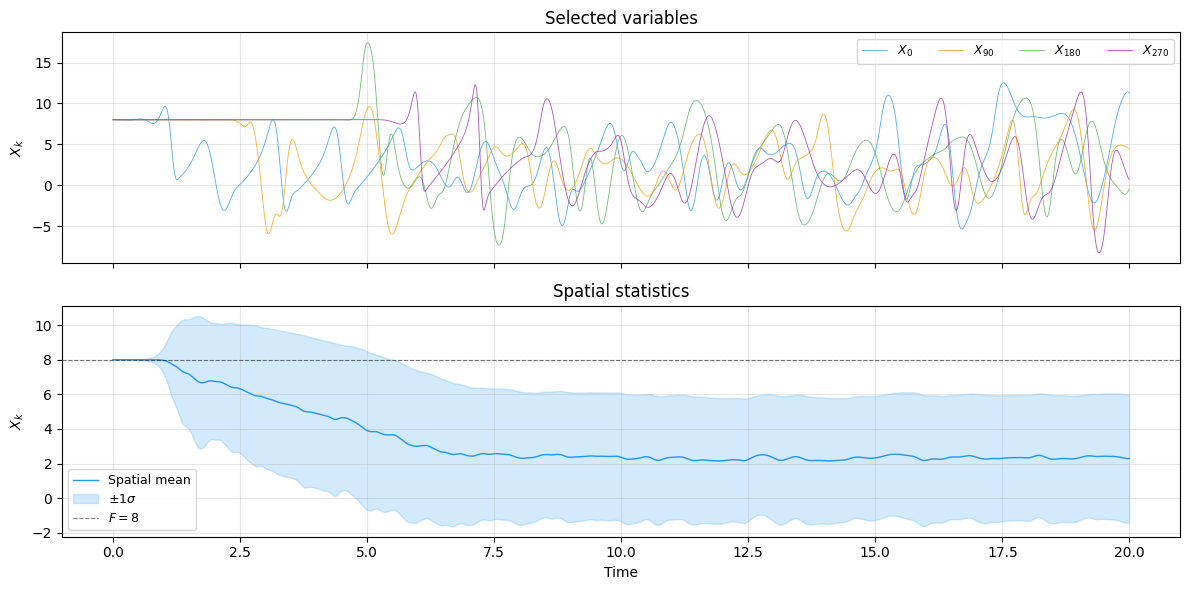

In [5]:
colors = ["#2196F3", "#FF9800", "#4CAF50", "#9C27B0", "#F44336"]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Top: a few selected variables
ax = axes[0]
for i, c in zip([0, 90, 180, 270], colors, strict=False):
    ax.plot(ts, sol.ys.x[:, i], lw=0.6, alpha=0.8, color=c, label=f"$X_{{{i}}}$")
ax.set_ylabel("$X_k$")
ax.set_title("Selected variables")
ax.legend(fontsize=9, ncol=4)
ax.grid(True, alpha=0.3)

# Bottom: spatial mean and std
spatial_mean = jnp.mean(sol.ys.x, axis=1)
spatial_std = jnp.std(sol.ys.x, axis=1)
ax = axes[1]
ax.plot(ts, spatial_mean, lw=1, color="#2196F3", label="Spatial mean")
ax.fill_between(
    ts,
    spatial_mean - spatial_std,
    spatial_mean + spatial_std,
    alpha=0.2,
    color="#2196F3",
    label=r"$\pm 1\sigma$",
)
ax.axhline(8.0, color="k", ls="--", lw=0.8, alpha=0.5, label="$F = 8$")
ax.set_xlabel("Time")
ax.set_ylabel("$X_k$")
ax.set_title("Spatial statistics")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Diagnostics

`model.diagnose()` returns the total energy
$E = \tfrac{1}{2} \sum_k X_k^2$ and the spatial mean.

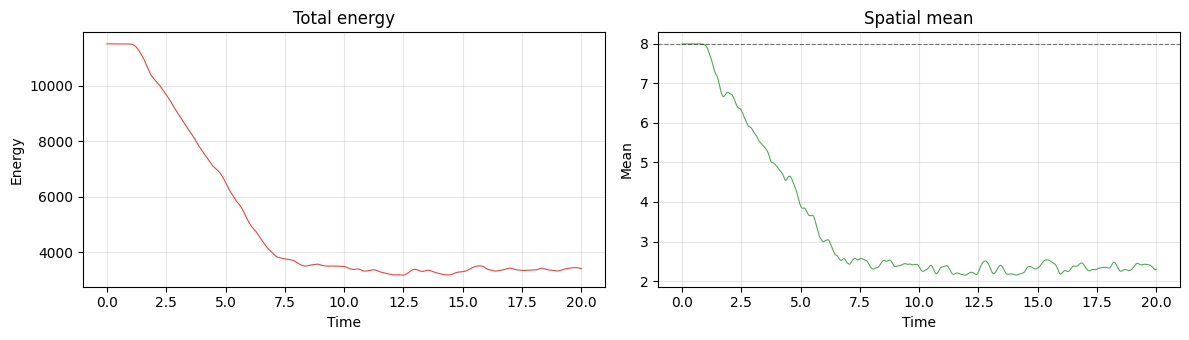

In [6]:
diags = jax.vmap(model.diagnose)(sol.ys)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].plot(ts, diags.energy, lw=0.8, color="#F44336")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Energy")
axes[0].set_title("Total energy")
axes[0].grid(True, alpha=0.3)

axes[1].plot(ts, diags.mean, lw=0.8, color="#4CAF50")
axes[1].axhline(8.0, color="k", ls="--", lw=0.8, alpha=0.5)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Mean")
axes[1].set_title("Spatial mean")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Forcing regimes

The Lorenz '96 system transitions from steady state to periodic
to chaotic as $F$ increases. We compare three regimes.

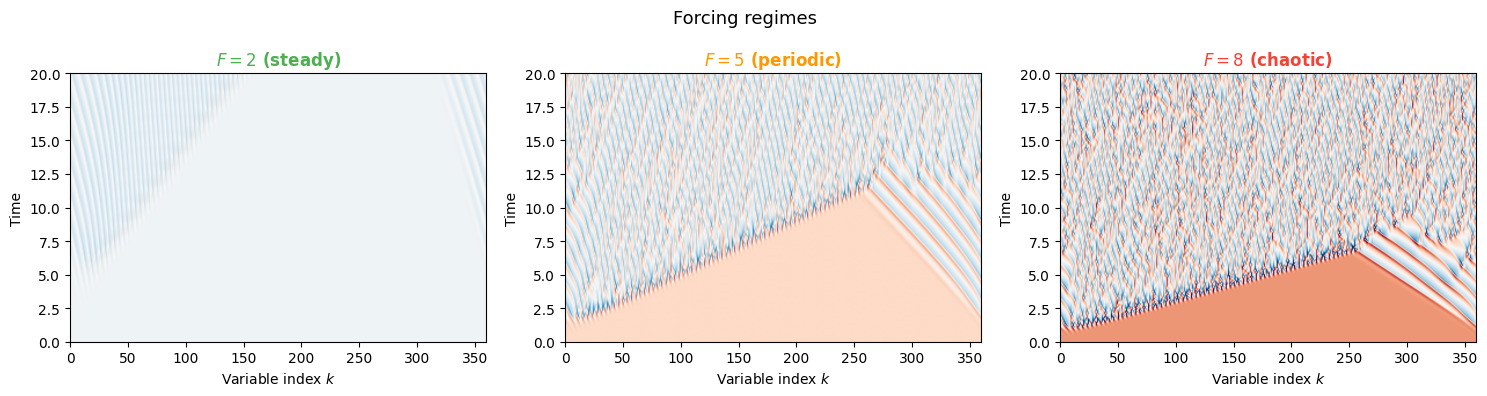

In [7]:
F_values = [2.0, 5.0, 8.0]
regime_labels = ["$F=2$ (steady)", "$F=5$ (periodic)", "$F=8$ (chaotic)"]
regime_colors = ["#4CAF50", "#FF9800", "#F44336"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, F_val, label, color in zip(
    axes, F_values, regime_labels, regime_colors, strict=True
):
    m = Lorenz96.create(F=F_val)
    s0 = L96State.init_state(ndim=N, noise=0.01, F=F_val)
    s = m.integrate(s0, t0=0.0, t1=20.0, dt=0.005, saveat=dfx.SaveAt(ts=ts))
    ax.imshow(
        s.ys.x,
        aspect="auto",
        origin="lower",
        cmap="RdBu_r",
        vmin=-10,
        vmax=15,
        extent=[0, N, 0, 20],
        interpolation="bilinear",
    )
    ax.set_xlabel("Variable index $k$")
    ax.set_ylabel("Time")
    ax.set_title(label, color=color, fontweight="bold")

plt.suptitle("Forcing regimes", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Adjoint methods and differentiation

diffrax supports several adjoint methods for backpropagating
through `diffeqsolve`. Each trades off memory, accuracy, and speed:

| Adjoint | Memory | Gradients | Best for |
|---------|--------|-----------|----------|
| `RecursiveCheckpointAdjoint` | $O(\sqrt{N})$ | Exact | **Default** |
| `DirectAdjoint` | $O(N)$ | Exact | Short windows, forward-mode AD |
| `BacksolveAdjoint` | $O(1)$ | Approximate | Very long windows, memory-critical |

`RecursiveCheckpointAdjoint` (the default) uses optimal
checkpointing: it re-computes forward steps from saved checkpoints
during the backward pass, giving exact gradients with sub-linear
memory.

### 7a. Gradient w.r.t. parameters

**Use case: parameter estimation.** Find the forcing $F$ that
minimizes a cost function over the trajectory:

$$
\frac{\partial \mathcal{L}}{\partial F}
= \int_0^T \lambda(t)^\top
  \frac{\partial f}{\partial F}\, dt
$$

In [8]:
state0_grad = L96State.init_state(ndim=N, noise=0.01, F=8.0)


@eqx.filter_grad
def grad_params(model):
    sol = model.integrate(state0_grad, t0=0.0, t1=1.0, dt=0.005)
    return jnp.sum(sol.ys.x**2)


grads_theta = grad_params(model)
print("--- Gradient w.r.t. parameters ---")
print(f"  dL/dF = {grads_theta.params.F:.4f}")

--- Gradient w.r.t. parameters ---
  dL/dF = 3630.4766


### 7b. Gradient w.r.t. initial state

**Use case: 4D-Var data assimilation.** Find the initial condition
$\mathbf{X}_0$ that best fits observations. The gradient is the
adjoint state at $t = 0$:

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{X}_0} = \lambda(0)
$$

In [9]:


def loss_state(state0):
    sol = model.integrate(state0, t0=0.0, t1=1.0, dt=0.005)
    return jnp.sum(sol.ys.x**2)


grads_u0 = jax.grad(loss_state)(state0_grad)

print("--- Gradient w.r.t. initial state ---")
print(f"  dL/d(X0) shape: {grads_u0.x.shape}")
print(f"  dL/d(X0) norm:  {jnp.linalg.norm(grads_u0.x):.4f}")
print(f"  dL/d(X0)[:5]:   {grads_u0.x[:5]}")

--- Gradient w.r.t. initial state ---
  dL/d(X0) shape: (360,)
  dL/d(X0) norm:  4228.1538
  dL/d(X0)[:5]:   [-1638.6827   -413.43512  1382.2256   1065.4902   -724.1401 ]


### 7c. Joint gradient — parameters and state

**Use case: weak-constraint 4D-Var / bi-level optimization.**
Simultaneously optimize the initial condition and model parameters.

In [10]:


def loss_joint(state0, model):
    sol = model.integrate(state0, t0=0.0, t1=1.0, dt=0.005)
    return jnp.sum(sol.ys.x**2)


grads_u0_joint, grads_model_joint = jax.grad(loss_joint, argnums=(0, 1))(
    state0_grad, model
)

print("--- Joint gradient ---")
print(f"  dL/dF         = {grads_model_joint.params.F:.4f}")
print(f"  dL/d(X0) norm = {jnp.linalg.norm(grads_u0_joint.x):.4f}")

--- Joint gradient ---
  dL/dF         = 3630.4766
  dL/d(X0) norm = 4228.1538


### 7d. Comparing adjoint methods

We time `RecursiveCheckpointAdjoint` vs `DirectAdjoint`.
`BacksolveAdjoint` requires a different API pattern (explicit
args to `diffeqsolve`, not via closure) — see the
[diffrax docs](https://docs.kidger.site/diffrax/api/adjoints/).

In [11]:
import time


def timed_grad(adjoint, label):
    @eqx.filter_grad
    def fn(model):
        sol = model.integrate(state0_grad, t0=0.0, t1=1.0, dt=0.005, adjoint=adjoint)
        return jnp.sum(sol.ys.x**2)

    g = fn(model)
    jax.block_until_ready(g.params.F)
    t_start = time.perf_counter()
    g = fn(model)
    jax.block_until_ready(g.params.F)
    elapsed = time.perf_counter() - t_start
    print(f"  {label:25s}  dL/dF={g.params.F:.2f}  ({elapsed:.4f}s)")


print("--- Adjoint method comparison ---")
timed_grad(dfx.RecursiveCheckpointAdjoint(), "RecursiveCheckpoint")
timed_grad(dfx.DirectAdjoint(), "Direct")

--- Adjoint method comparison ---


  RecursiveCheckpoint        dL/dF=3630.48  (3.4910s)


  Direct                     dL/dF=3630.47  (2.5467s)


## 8. Ensemble forecast divergence

We launch 30 ensemble members from perturbed initial conditions
and measure the ensemble spread over time — the hallmark of
deterministic chaos.

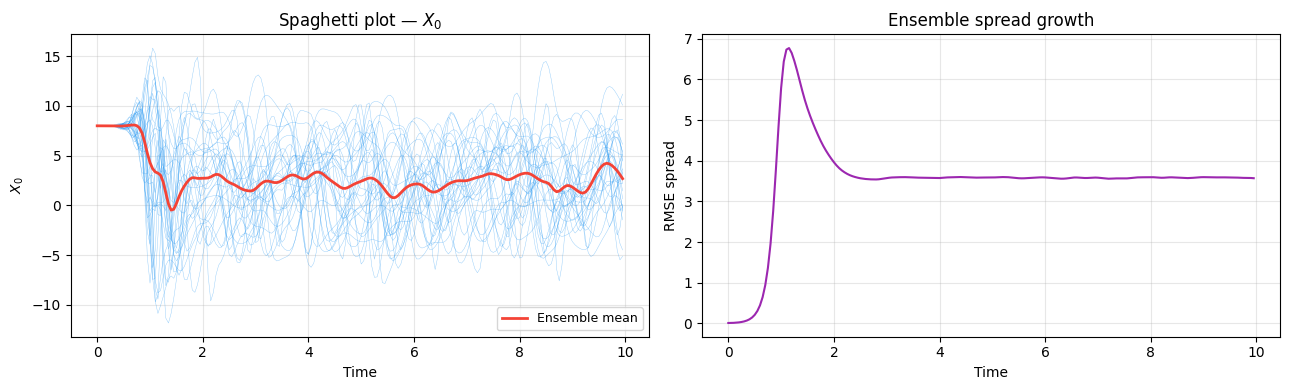

In [12]:
n_ensemble = 30
key = jrandom.PRNGKey(0)
perturb = 0.01 * jrandom.normal(key, shape=(n_ensemble, N))
x0_base = 8.0 * jnp.ones(N)
ensemble_states = L96State(x=x0_base[None, :] + perturb)

ts_ens = jnp.arange(0.0, 10.0, 0.05)


def integrate_one(state0):
    return model.integrate(
        state0,
        t0=0.0,
        t1=10.0,
        dt=0.005,
        saveat=dfx.SaveAt(ts=ts_ens),
    )


ensemble_sol = eqx.filter_vmap(integrate_one)(ensemble_states)

# Compute ensemble spread (RMSE relative to ensemble mean)
ens_mean = jnp.mean(ensemble_sol.ys.x, axis=0)  # (T, N)
spread = jnp.sqrt(
    jnp.mean((ensemble_sol.ys.x - ens_mean[None, :, :]) ** 2, axis=(0, 2))
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: spaghetti plot for variable 0
ax = axes[0]
for j in range(n_ensemble):
    ax.plot(ts_ens, ensemble_sol.ys.x[j, :, 0], lw=0.3, alpha=0.5, color="#2196F3")
ax.plot(ts_ens, ens_mean[:, 0], lw=2, color="#F44336", label="Ensemble mean")
ax.set_xlabel("Time")
ax.set_ylabel("$X_0$")
ax.set_title("Spaghetti plot — $X_0$")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: ensemble spread
ax = axes[1]
ax.plot(ts_ens, spread, lw=1.5, color="#9C27B0")
ax.set_xlabel("Time")
ax.set_ylabel("RMSE spread")
ax.set_title("Ensemble spread growth")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

| Concept | somax API |
|---------|-----------|
| Create a model | `Lorenz96.create(F=8.0)` |
| Initial condition | `L96State.init_state(ndim=40, F=8.0)` |
| Forward simulation | `model.integrate(state0, t0, t1, dt, saveat=...)` |
| Diagnostics | `model.diagnose(state)` — energy, mean |
| Grad w.r.t. params | `eqx.filter_grad(loss)(model)` — dL/dF |
| Grad w.r.t. state | `jax.grad(loss)(state0)` — dL/dX0 |
| Joint grad | `jax.grad(loss, argnums=(0, 1))(state0, model)` |
| Ensemble | `eqx.filter_vmap(integrate_one)(batch_states)` |

**Key takeaways:**

- $F = 8$ produces fully developed chaos with a doubling time of
  ~0.42 time units
- The Hovmoller diagram reveals eastward-propagating wave packets
- Ensemble spread saturates after ~4 time units (the predictability
  horizon)